<a href="https://colab.research.google.com/github/flynnava/Global-Poverty-and-Inequality-Trends/blob/main/Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Research Question:
How do global crises influence the relationship between income inequality and poverty?

(4877, 108)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4877 entries, 0 to 4876
Columns: 108 entries, country to p50_p10_ratio
dtypes: float64(103), int64(2), object(3)
memory usage: 4.0+ MB
Duplicates: 0
(4049, 108)
['country', 'year', 'reporting_level', 'welfare_type', 'ppp_version', 'survey_year', 'survey_comparability', 'headcount_ratio_international_povline', 'headcount_ratio_lower_mid_income_povline', 'headcount_ratio_upper_mid_income_povline', 'headcount_ratio_100', 'headcount_ratio_1000', 'headcount_ratio_2000', 'headcount_ratio_3000', 'headcount_ratio_4000', 'headcount_ratio_40_median', 'headcount_ratio_50_median', 'headcount_ratio_60_median', 'headcount_international_povline', 'headcount_lower_mid_income_povline', 'headcount_upper_mid_income_povline', 'headcount_100', 'headcount_1000', 'headcount_2000', 'headcount_3000', 'headcount_4000', 'headcount_40_median', 'headcount_50_median', 'headcount_60_median', 'avg_shortfall_international_povline', 'avg_shortfall_lower_mid_

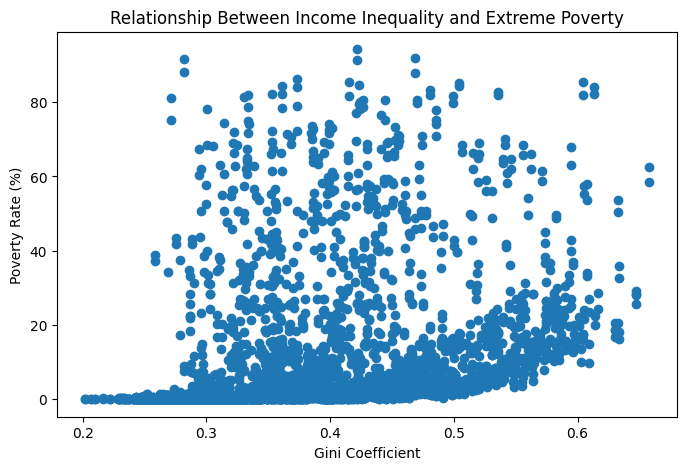

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("poverty_original.csv")

# Create a copy
clean_df = df.copy()

# Inspects the data
print(clean_df.shape)
clean_df.head()
clean_df.info()
clean_df.describe()

# Check for missing values
clean_df.isnull().sum().sort_values(ascending=False)

# Removes duplicate rows
print("Duplicates:", clean_df.duplicated().sum())
clean_df = clean_df.drop_duplicates()

# Keeps only country level observations
clean_df = clean_df[
    clean_df["reporting_level"] == "national"
]

print(clean_df.shape)

# Check column names
print(clean_df.columns.tolist())

# Converts data types
clean_df["year"] = clean_df["year"].astype(int)
categorical = [
    "country",
    "reporting_level",
    "welfare_type"
]
for col in categorical:
    clean_df[col] = clean_df[col].astype("category")

# Keep only variables I need
research_df = clean_df[[
    "country",
    "year",
    "gini",
    "palma_ratio",
    "headcount_ratio_international_povline",
    "headcount_ratio_lower_mid_income_povline",
    "headcount_ratio_upper_mid_income_povline",
    "mean",
    "median",
    "welfare_type"
]]

# Check for impossible values
research_df.describe()

# Save cleaned data
research_df.to_csv(
    "poverty_clean.csv",
    index=False
)
# Creates a visulization of Gini coefficient and poverty rate increase
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    clean_df["gini"],
    clean_df["headcount_ratio_international_povline"]
)

plt.xlabel("Gini Coefficient")
plt.ylabel("Poverty Rate (%)")
plt.title("Relationship Between Income Inequality and Extreme Poverty")

plt.show()

Explination of the visulization:
---



The scatterplot shows the relationship between income inequality and extreme poverty. The overall trend suggests that countries with higher Gini coefficients tend to have higher poverty rates, indicating that greater income inequality may be associated with increased poverty. However, the spead of points suggests that other factors may also influence poverty levels.